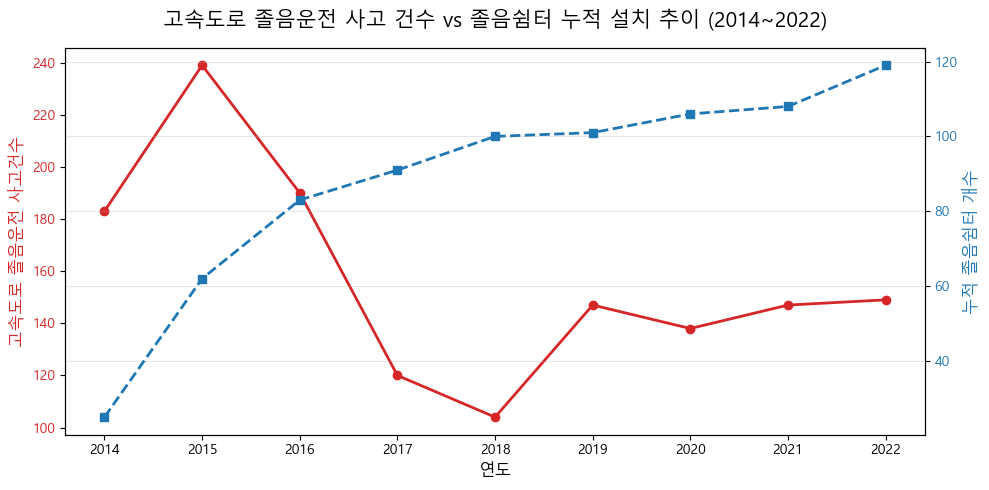

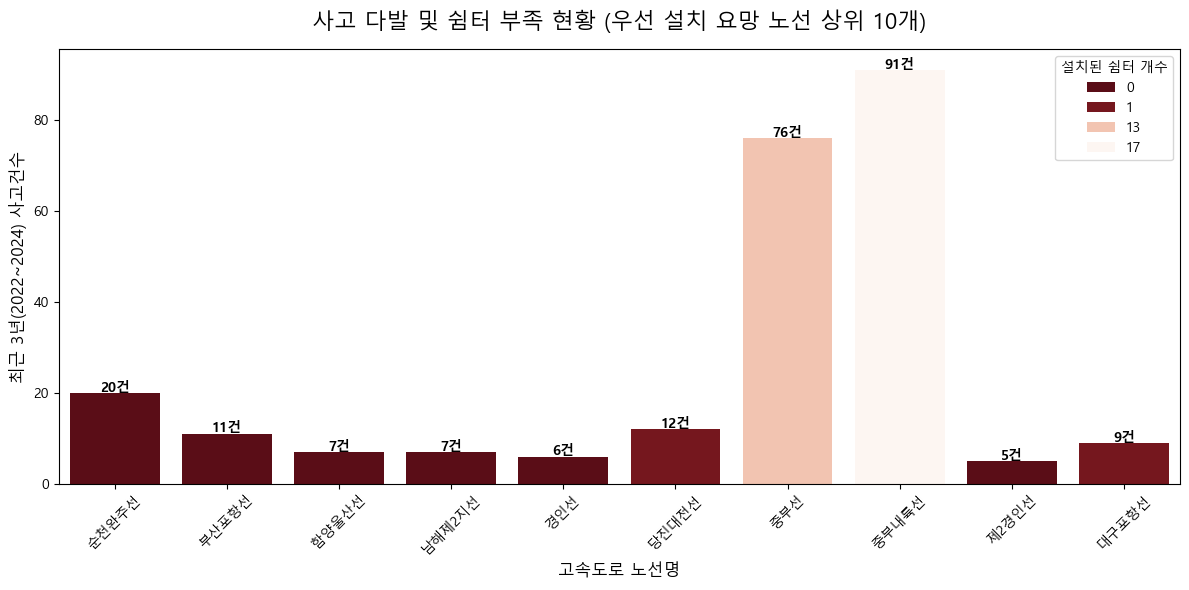

분석이 완료되었습니다! '분석결과_노선별위험도.csv' 파일이 저장되었습니다.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 폰트 및 시각화 설정 (윈도우 환경)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_palette("muted")

# 2. 작업 경로 지정
base_path = r"C:\Project\Python_Source\python311_01\pandas_ex\project_1"

# 3. [핵심] 인코딩 오류 방지용 파일 로더 함수
def read_korean_csv(filename):
    file_path = os.path.join(base_path, filename)
    encodings = ['cp949', 'utf-8-sig', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except (UnicodeDecodeError, LookupError, FileNotFoundError):
            continue
    raise ValueError(f"파일을 읽을 수 없습니다: {filename}")

# ==========================================
# [데이터 로드]
# ==========================================
# 1) 경찰청 도로종류별 사고 현황 (과거~최근)
df_acc_old = read_korean_csv('경찰청 도로종류별 졸음운전 교통사고 현황(2014~2016).csv')
df_acc_new = read_korean_csv('경찰청 졸음운전 교통사고 현황(2017-2022).csv')

# 2) 도로공사 사고 및 쉼터 현황 (최근)
df_hw_acc = read_korean_csv('한국도로공사_졸음운전 사고통계(2022~2024).csv')
df_shelter = read_korean_csv('한국도로공사 졸음쉼터 설치현황(2024년).csv')


# ==========================================
# [분석 1] 졸음쉼터가 늘어나면 사고가 줄었을까? (2014~2022 장기 추세)
# ==========================================
# 고속국도 데이터만 추출 및 병합
acc_14_16 = df_acc_old[df_acc_old['구분'] == '고속국도'][['년도', '사고(건)']].rename(columns={'년도':'연도', '사고(건)':'사고건수'})
acc_17_22 = df_acc_new[df_acc_new['도로종류'] == '고속국도'][['연도', '사고_건']].rename(columns={'사고_건':'사고건수'})
acc_trend = pd.concat([acc_14_16, acc_17_22], ignore_index=True)

# 졸음쉼터 연도별 누적수 계산 (2014~2022년 사이)
shelter_yearly = df_shelter.groupby('설치년도').size().reset_index(name='신규설치')
shelter_yearly = shelter_yearly[(shelter_yearly['설치년도'] >= 2014) & (shelter_yearly['설치년도'] <= 2022)].copy()
shelter_yearly['누적설치수'] = shelter_yearly['신규설치'].cumsum()

# 시각화 1 (이중 축 그래프)
fig, ax1 = plt.subplots(figsize=(10, 5))
color_acc = 'tab:red'
ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('고속도로 졸음운전 사고건수', color=color_acc, fontsize=12)
ax1.plot(acc_trend['연도'], acc_trend['사고건수'], color=color_acc, marker='o', linewidth=2, label='사고 건수')
ax1.tick_params(axis='y', labelcolor=color_acc)

ax2 = ax1.twinx()
color_sh = 'tab:blue'
ax2.set_ylabel('누적 졸음쉼터 개수', color=color_sh, fontsize=12)
ax2.plot(shelter_yearly['설치년도'], shelter_yearly['누적설치수'], color=color_sh, marker='s', linestyle='--', linewidth=2, label='누적 쉼터 수')
ax2.tick_params(axis='y', labelcolor=color_sh)

plt.title('고속도로 졸음운전 사고 건수 vs 졸음쉼터 누적 설치 추이 (2014~2022)', fontsize=15, pad=15)
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()


# ==========================================
# [분석 2] 어느 노선에 졸음쉼터를 더 지어야 할까? (위험도 분석)
# ==========================================
# 노선명 통일화 작업 (사고데이터와 쉼터데이터의 표기법 일치)
def map_route_name(name):
    if pd.isna(name): return name
    name = str(name)
    if '남해선(순천부산)' in name or '남해선(영암순천)' in name: return '남해선'
    if '청주영덕' in name: return '청주영덕선'
    if '당진대전' in name: return '당진대전선'
    if '당진청주' in name: return '당진청주선'
    if '호남지선' in name: return '호남선의 지선'
    if '대구포항' in name: return '대구포항선'
    if '익산장수' in name: return '익산장수선'
    if '서울외곽' in name: return '수도권제1순환선'
    return name

df_shelter['정제된노선'] = df_shelter['노선'].apply(map_route_name)
shelter_count = df_shelter.groupby('정제된노선').size().reset_index(name='쉼터개수')
acc_count = df_hw_acc.groupby('노선명').size().reset_index(name='사고건수')

# 병합 및 위험도 산출
merged = pd.merge(acc_count, shelter_count, left_on='노선명', right_on='정제된노선', how='left')
merged['쉼터개수'] = merged['쉼터개수'].fillna(0).astype(int)
merged.drop(columns=['정제된노선'], inplace=True)

# 쉼터 1개당 커버해야 하는 사고 건수 (위험도) - 분모 0 방지 위해 쉼터+1 적용
merged['위험도'] = merged['사고건수'] / (merged['쉼터개수'] + 1)

# 위험도가 높은 최상위 10개 노선 추출
high_risk_routes = merged.sort_values('위험도', ascending=False).head(10)

# 시각화 2 (바 차트)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=high_risk_routes, 
    x='노선명', 
    y='사고건수', 
    hue='쉼터개수', 
    dodge=False, 
    palette='Reds_r'
)

plt.title('사고 다발 및 쉼터 부족 현황 (우선 설치 요망 노선 상위 10개)', fontsize=16, pad=15)
plt.xlabel('고속도로 노선명', fontsize=12)
plt.ylabel('최근 3년(2022~2024) 사고건수', fontsize=12)

# 막대 위에 사고 건수 텍스트 추가
for i, v in enumerate(high_risk_routes['사고건수']):
    plt.text(i, v + 0.3, f"{v}건", ha='center', fontweight='bold')

plt.legend(title='설치된 쉼터 개수', loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 엑셀 파일로 결과 저장하기 (분석 보고서 활용용)
merged.sort_values('위험도', ascending=False).to_csv(os.path.join(base_path, "분석결과_노선별위험도.csv"), index=False, encoding='utf-8-sig')
print("분석이 완료되었습니다! '분석결과_노선별위험도.csv' 파일이 저장되었습니다.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 폰트 및 시각화 설정 (윈도우 환경)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_palette("muted")

# 2. 작업 경로 지정
base_path = r"C:\Project\Python_Source\python311_01\pandas_ex\project_1"

# 3. [핵심] 인코딩 오류 방지용 파일 로더 함수
def read_korean_csv(filename):
    file_path = os.path.join(base_path, filename)
    encodings = ['cp949', 'utf-8-sig', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except (UnicodeDecodeError, LookupError, FileNotFoundError):
            continue
    raise ValueError(f"파일을 읽을 수 없습니다: {filename}")

# ==========================================
# [데이터 로드]
# ==========================================
# 1) 경찰청 도로종류별 사고 현황 (과거~최근)
df_acc_old = read_korean_csv('경찰청 도로종류별 졸음운전 교통사고 현황(2014~2016).csv')
df_acc_new = read_korean_csv('경찰청 졸음운전 교통사고 현황(2017-2022).csv')

# 2) 도로공사 사고 및 쉼터 현황 (최근)
df_hw_acc = read_korean_csv('한국도로공사_졸음운전 사고통계(2022~2024).csv')
df_shelter = read_korean_csv('한국도로공사 졸음쉼터 설치현황(2024년).csv')


# ==========================================
# [분석 1] 졸음쉼터가 늘어나면 사고가 줄었을까? (2014~2022 장기 추세)
# ==========================================
# 고속국도 데이터만 추출 및 병합
acc_14_16 = df_acc_old[df_acc_old['구분'] == '고속국도'][['년도', '사고(건)']].rename(columns={'년도':'연도', '사고(건)':'사고건수'})
acc_17_22 = df_acc_new[df_acc_new['도로종류'] == '고속국도'][['연도', '사고_건']].rename(columns={'사고_건':'사고건수'})
acc_trend = pd.concat([acc_14_16, acc_17_22], ignore_index=True)

# 졸음쉼터 연도별 누적수 계산 (2014~2022년 사이)
shelter_yearly = df_shelter.groupby('설치년도').size().reset_index(name='신규설치')
shelter_yearly = shelter_yearly[(shelter_yearly['설치년도'] >= 2014) & (shelter_yearly['설치년도'] <= 2022)].copy()
shelter_yearly['누적설치수'] = shelter_yearly['신규설치'].cumsum()

# 시각화 1 (이중 축 그래프)
fig, ax1 = plt.subplots(figsize=(10, 5))
color_acc = 'tab:red'
ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('고속도로 졸음운전 사고건수', color=color_acc, fontsize=12)
ax1.plot(acc_trend['연도'], acc_trend['사고건수'], color=color_acc, marker='o', linewidth=2, label='사고 건수')
ax1.tick_params(axis='y', labelcolor=color_acc)

ax2 = ax1.twinx()
color_sh = 'tab:blue'
ax2.set_ylabel('누적 졸음쉼터 개수', color=color_sh, fontsize=12)
ax2.plot(shelter_yearly['설치년도'], shelter_yearly['누적설치수'], color=color_sh, marker='s', linestyle='--', linewidth=2, label='누적 쉼터 수')
ax2.tick_params(axis='y', labelcolor=color_sh)

plt.title('고속도로 졸음운전 사고 건수 vs 졸음쉼터 누적 설치 추이 (2014~2022)', fontsize=15, pad=15)
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()


# ==========================================
# [분석 2] 어느 노선에 졸음쉼터를 더 지어야 할까? (위험도 분석 - 시각화 제거, 데이터만 추출)
# ==========================================
# 노선명 통일화 작업 (사고데이터와 쉼터데이터의 표기법 일치)
def map_route_name(name):
    if pd.isna(name): return name
    name = str(name)
    if '남해선(순천부산)' in name or '남해선(영암순천)' in name: return '남해선'
    if '청주영덕' in name: return '청주영덕선'
    if '당진대전' in name: return '당진대전선'
    if '당진청주' in name: return '당진청주선'
    if '호남지선' in name: return '호남선의 지선'
    if '대구포항' in name: return '대구포항선'
    if '익산장수' in name: return '익산장수선'
    if '서울외곽' in name: return '수도권제1순환선'
    return name

df_shelter['정제된노선'] = df_shelter['노선'].apply(map_route_name)
shelter_count = df_shelter.groupby('정제된노선').size().reset_index(name='쉼터개수')
acc_count = df_hw_acc.groupby('노선명').size().reset_index(name='사고건수')

# 병합 및 위험도 산출
merged = pd.merge(acc_count, shelter_count, left_on='노선명', right_on='정제된노선', how='left')
merged['쉼터개수'] = merged['쉼터개수'].fillna(0).astype(int)
merged.drop(columns=['정제된노선'], inplace=True)

# 쉼터 1개당 커버해야 하는 사고 건수 (위험도) - 분모 0 방지 위해 쉼터+1 적용
merged['위험도'] = merged['사고건수'] / (merged['쉼터개수'] + 1)

# 엑셀 파일로 결과 저장하기 (분석 보고서 활용용)
merged.sort_values('위험도', ascending=False).to_csv(os.path.join(base_path, "분석결과_노선별위험도.csv"), index=False, encoding='utf-8-sig')
print("분석이 완료되었습니다! 잡다한 막대그래프는 치우고 '분석결과_노선별위험도.csv' 파일만 깔끔하게 뽑아냈습니다.")